[Previous: GoF 2: Structural Patterns, Part 1](02_Structural_Part_1.ipynb)  |  [Course Index](../00_Start_Here.ipynb)  |  [Next: GoF 4: Behavioral Patterns, Part 1](04_Behavioral_Part_1.ipynb)

# GoF 3: Structural Patterns, Part 2

**Learning objectives.** After this module you can:

* hide a complicated subsystem behind a Facade and show, with a trace, what it saves the client;
* cut memory with Flyweight by separating shared state from per-object state, and measure the saving;
* control access to an object with a Proxy for lazy loading, permissions and caching, using `__getattr__` to forward the rest.

## 1. Facade

**Problem.** Starting a movie means talking to the amplifier, the projector, the lights and the player, in the right order. Every caller would repeat that dance.

**Structure.** One class with a simple method per use case, which orchestrates the subsystem. The subsystem classes stay available for anyone who needs the detail.

playing Arrival


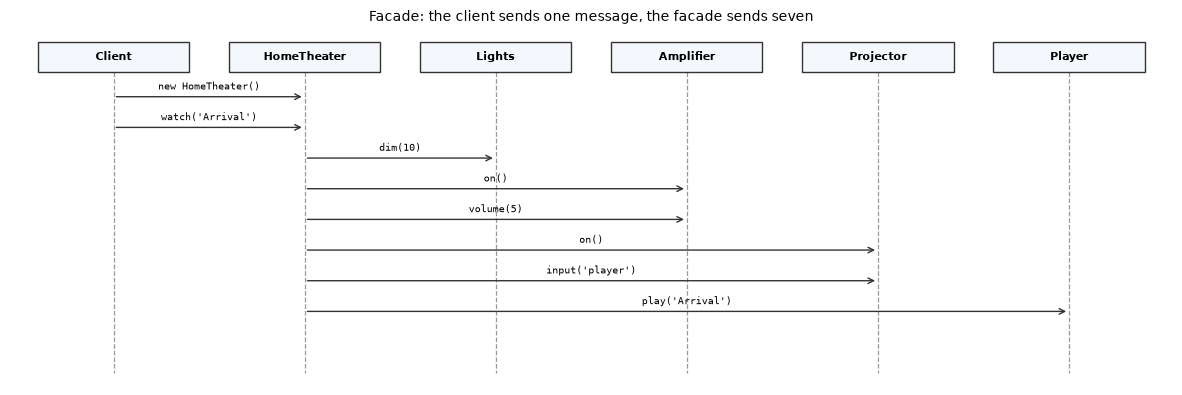

In [1]:
from dplab import class_diagram, traced, trace

@traced
class Amplifier:
    def on(self): pass
    def volume(self, level): pass

@traced
class Projector:
    def on(self): pass
    def input(self, source): pass

@traced
class Lights:
    def dim(self, percent): pass

@traced
class Player:
    def play(self, title): return f"playing {title}"

@traced
class HomeTheater:                                   # the facade
    def __init__(self):
        self.amp, self.projector, self.lights, self.player = Amplifier(), Projector(), Lights(), Player()

    def watch(self, title):
        self.lights.dim(10)
        self.amp.on(); self.amp.volume(5)
        self.projector.on(); self.projector.input("player")
        return self.player.play(title)

with trace() as t:
    theater = HomeTheater()
    print(theater.watch("Arrival"))
t.diagram(title="Facade: the client sends one message, the facade sends seven")

> **What to notice.** The client made one call. Everything below the first arrow is the facade's business. If the projector API changes, one class changes.

## 2. Flyweight

**Problem.** A forest of 200,000 trees, each with a species name, colour and a texture. If every tree carries its own copy, memory explodes; there are only five species.

**Structure.** Split state into **intrinsic** (shared, immutable: the species data) and **extrinsic** (per object: position). Trees hold a reference to a shared `TreeType`; a factory hands out the shared instances.

In [2]:
import tracemalloc

class TreeType:                              # intrinsic state, shared
    def __init__(self, name):
        self.name = name
        self.texture = name * 60             # stands in for image data

class Tree:                                  # extrinsic state, one per tree
    __slots__ = ("x", "y", "kind")
    def __init__(self, x, y, kind):
        self.x, self.y, self.kind = x, y, kind

class TreeFactory:
    types = {}
    @classmethod
    def get(cls, name):
        if name not in cls.types:
            cls.types[name] = TreeType(name)
        return cls.types[name]

def plant(n, shared):
    tracemalloc.start()
    forest = [Tree(i % 500, i // 500, TreeFactory.get(name) if shared else TreeType(name))
              for i, name in zip(range(n), ["oak", "pine", "birch", "maple", "willow"] * (n // 5 + 1))]
    used, _ = tracemalloc.get_traced_memory()
    tracemalloc.stop()
    return used

n = 100_000
without, with_fw = plant(n, shared=False), plant(n, shared=True)
print(f"{n:,} trees:  one TreeType each {without / 1e6:.1f} MB   shared types {with_fw / 1e6:.1f} MB   saving {1 - with_fw / without:.0%}")

100,000 trees:  one TreeType each 48.5 MB   shared types 8.0 MB   saving 84%


### Lab: Flyweight Lab

Drag the number of trees and compare the two bars. The per-tree cost with sharing is just the position and one reference.

Flyweight Lab (static preview). Run this cell in JupyterLab for the interactive version.


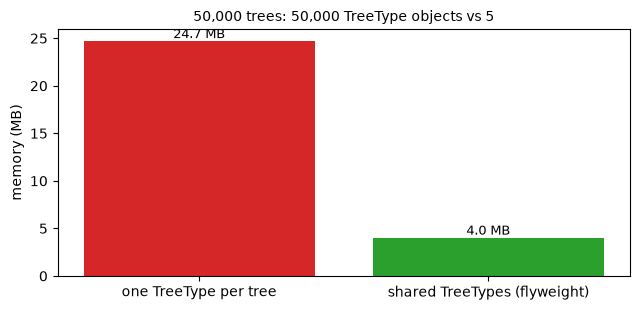

In [3]:
from dplab import flyweight_lab

flyweight_lab()

## 3. Proxy

**Problem.** You want to control access to an object without the client noticing: create it only when first used (virtual proxy), check permissions (protection proxy),
cache results (caching proxy), or talk to it over a network (remote proxy).

**Structure.** The proxy has the same interface as the real object and holds (or creates) it. In Python, `__getattr__` forwards everything you did not override.

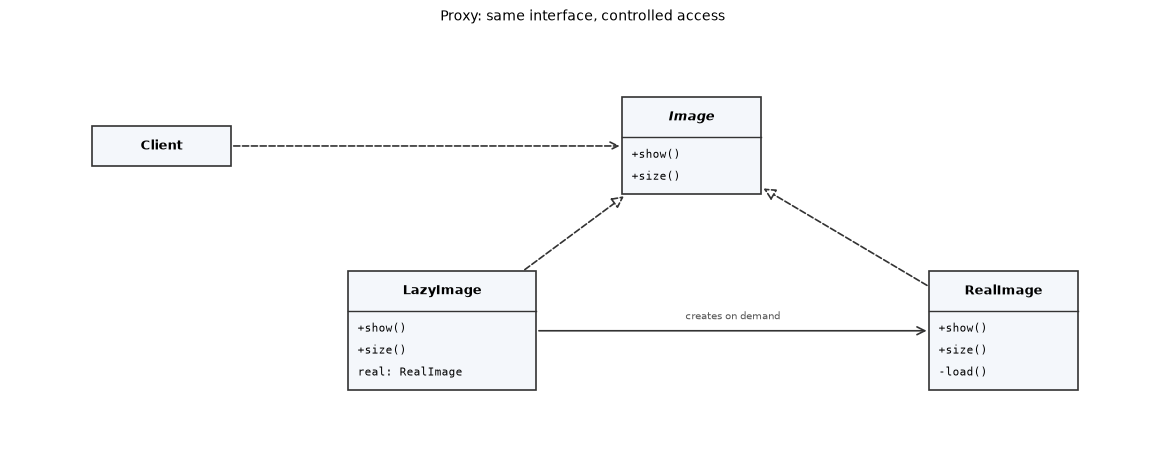

In [4]:
class_diagram(
    {"Image": ["+show()", "+size()"], "RealImage": ["+show()", "+size()", "-load()"], "LazyImage": ["+show()", "+size()", "real: RealImage"], "Client": []},
    [("RealImage", "Image", "implements"), ("LazyImage", "Image", "implements"), ("LazyImage", "RealImage", "refers", "creates on demand"), ("Client", "Image", "uses")],
    abstract={"Image"}, layout={"Client": (-1.5, 0), "Image": (0.2, 0), "LazyImage": (-0.6, 1), "RealImage": (1.2, 1)},
    title="Proxy: same interface, controlled access")

sizes: [(4000, 3000), (4000, 3000), (4000, 3000)]
<photo1.jpg: 4000 x 3000 pixels>


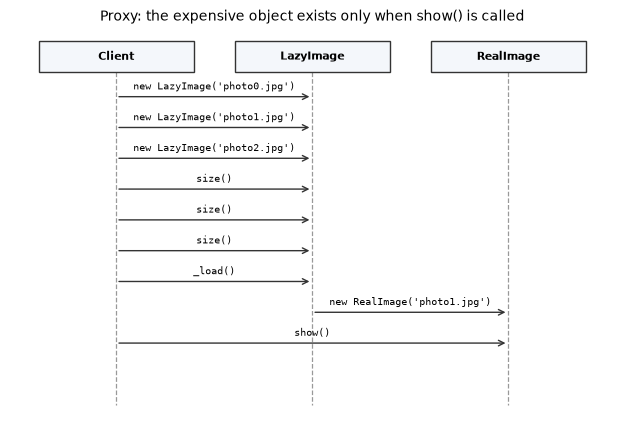

In [5]:
import time

@traced
class RealImage:
    def __init__(self, path):
        self.path = path
        time.sleep(0.05)                        # pretend the file is big
        self.pixels = f"<{path}: 4000 x 3000 pixels>"

    def show(self):
        return self.pixels

    def size(self):
        return (4000, 3000)

@traced
class LazyImage:                                 # virtual proxy: loads on first real use
    def __init__(self, path):
        self.path = path
        self._real = None

    def _load(self):
        if self._real is None:
            self._real = RealImage(self.path)
        return self._real

    def size(self):
        return (4000, 3000)                      # answerable without loading

    def __getattr__(self, name):                 # everything else goes to the real image, loading it first
        if name.startswith("_"):                 # never forward private or dunder lookups: they cause infinite recursion
            raise AttributeError(name)
        return getattr(self._load(), name)

with trace() as t:
    gallery = [LazyImage(f"photo{i}.jpg") for i in range(3)]
    print("sizes:", [img.size() for img in gallery])          # no loading yet
    print(gallery[1].show())                                  # only photo1 is loaded
t.diagram(title="Proxy: the expensive object exists only when show() is called")

In [6]:
# Two more proxies in ten lines each.
class ProtectionProxy:
    def __init__(self, target, allowed_roles, role):
        self._target, self._allowed, self._role = target, allowed_roles, role
    def __getattr__(self, name):
        if self._role not in self._allowed:
            raise PermissionError(f"role {self._role!r} may not use {name}")
        return getattr(self._target, name)

class CachingProxy:
    def __init__(self, target):
        self._target, self._cache = target, {}
    def __getattr__(self, name):
        method = getattr(self._target, name)
        def cached(*args):
            key = (name, args)
            if key not in self._cache:
                self._cache[key] = method(*args)
            return self._cache[key]
        return cached

class Reports:
    def total(self, year):
        time.sleep(0.05)
        return year * 1000

admin = ProtectionProxy(Reports(), {"admin"}, "admin")
guest = ProtectionProxy(Reports(), {"admin"}, "guest")
print("admin:", admin.total(2025))
try:
    guest.total(2025)
except PermissionError as e:
    print("guest:", e)

fast = CachingProxy(Reports())
t0 = time.perf_counter(); fast.total(2025); first = time.perf_counter() - t0
t0 = time.perf_counter(); fast.total(2025); second = time.perf_counter() - t0
print(f"caching proxy: first call {first * 1000:.0f} ms, second call {second * 1000:.2f} ms")

admin: 2025000
guest: role 'guest' may not use total
caching proxy: first call 51 ms, second call 0.03 ms


> **What to notice.** `__getattr__` is only called for attributes the proxy does not have, so overriding a method (like `size`) and forwarding the rest takes no extra code.
> Always refuse names starting with an underscore in a forwarding `__getattr__`: during `__init__`, before `_real` exists, a lookup of `_real` would otherwise call `_load`, which looks up `_real`, forever.
> Decorator and Proxy look alike; the difference is intent: Decorator adds behaviour, Proxy controls access.

## Try it yourself

**Exercise 1.** Add `end()` to the `HomeTheater` facade that reverses the start-up sequence, and trace it.

**Exercise 2.** In the Flyweight example, what happens to memory if `TreeType` also stores a 10 KB texture string? Change `name * 60` to `name * 2000` and re-run the measurement.

**Exercise 3.** Write a `LoggingProxy` that prints every method call with its arguments before forwarding. Compare it with the `@traced` decorator from `dplab`.

**Exercise 4 (challenge).** Combine them: a `CachingProxy` around a `ProtectionProxy` around `Reports`. Does the order matter for correctness? For performance?

<details><summary>Solutions</summary>

```python
# Exercise 1
def end(self):
    self.player.play("stop"); self.projector.input("none"); self.amp.volume(0); self.lights.dim(100)
HomeTheater.end = end

# Exercise 2: without sharing, memory grows by about 10 KB per tree (a gigabyte for 100,000 trees); with sharing it does not move.

# Exercise 3
class LoggingProxy:
    def __init__(self, target): self._t = target
    def __getattr__(self, name):
        attr = getattr(self._t, name)
        if not callable(attr): return attr
        def call(*a, **k):
            print(f"{type(self._t).__name__}.{name}{a}")
            return attr(*a, **k)
        return call
# dplab.traced does the same by wrapping the class's methods, and records instead of printing.

# Exercise 4: CachingProxy(ProtectionProxy(...)) caches only allowed results, so a guest still fails: correct.
# ProtectionProxy(CachingProxy(...)) checks the role on every call and the cache is shared across roles: fine here, but a cached result could leak between roles if the check depended on the argument.
```

</details>

## Checkpoint quiz

Four quick questions. Answer them before reading the takeaways. If you miss one, the explanation points you to the section to re-read.

In [7]:
from dplab import quiz

quiz(3)

Checkpoint quiz, Module 3 (static preview). Run this cell in JupyterLab to answer interactively.

Q1. Facade
    a) hides a complex subsystem behind one simple entry point
    b) copies objects
    c) shares state between objects
    d) queues requests

Q2. Flyweight saves memory by
    a) compressing objects
    b) sharing the intrinsic (unchanging) state among many objects
    c) deleting unused objects
    d) lazy loading

Q3. A virtual proxy
    a) checks permissions
    b) delays creating an expensive object until it is really needed
    c) caches results
    d) forwards calls over the network

Q4. Which Python feature makes a forwarding Proxy almost free to write?
    a) __getattr__
    b) __init__
    c) @staticmethod
    d) list comprehensions


## Key takeaways

* Facade: one simple entry point over a subsystem; the subsystem keeps its full interface for those who need it.
* Flyweight: separate shared intrinsic state from per-object extrinsic state; a factory hands out the shared part.
* Proxy: same interface, controlled access. Virtual, protection, caching and remote are the common kinds. `__getattr__` forwards the rest.

**Next:** patterns about communication between objects. [GoF 4](04_Behavioral_Part_1.ipynb).

[Previous: GoF 2: Structural Patterns, Part 1](02_Structural_Part_1.ipynb)  |  [Course Index](../00_Start_Here.ipynb)  |  [Next: GoF 4: Behavioral Patterns, Part 1](04_Behavioral_Part_1.ipynb)